# Módulo 1: Análisis Exploratorio de Datos (EDA) y Preparación de Requerimientos

**Proyecto Integrador - Maestría en Inteligencia Artificial Aplicada**  
**Sistema Asignador de Requerimientos TI (ServiceNow)**

Este cuaderno realiza el análisis exploratorio exhaustivo, auditoría de calidad, consolidación de variables y resolución de ambigüedades sobre los tickets históricos de requerimientos bancarios.  
Al finalizar, exporta el conjunto de datos limpio y curado `Requerimientos_Preparados.csv`, que sirve como punto de partida estandarizado para los cuadernos de modelado (**02 Línea Base TF-IDF** y **03 Arquitectura HNLP-MC**).

## 1. Carga de Librerías y Configuración Inicial

In [1]:
# ── Librería estándar ─────────────────────────────────────────────────────────
import os
import re
import unicodedata
import warnings
from collections import Counter

# ── Datos y visualización ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')

# ── Procesamiento de texto ────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords

# ── Configuración de gráficos ────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (10, 6)})


## 2. Carga y Exploración Inicial de Datos

In [2]:
# Cargar el archivo CSV
# Ruta relativa desde Semisupervisado/ hacia Datos/ (un nivel arriba)
ruta_csv = "../Datos/RequerimientosCategorizados_v1.csv"
print('Directorio actual:', os.getcwd())
print('Ruta CSV:', ruta_csv)

# Intenta cargar el archivo
try:
    try:
        df = pd.read_csv(ruta_csv, sep=";", encoding="latin-1")
        if len(df.columns) == 1:
            raise ValueError("Wrong delimiter")
    except (ValueError, pd.errors.ParserError):
        df = pd.read_csv(ruta_csv, sep=",", encoding="latin-1")
except FileNotFoundError as e:
    print('No se encontró el archivo. Verifica la ruta y ubicación.')
    raise e

# Mostrar primeras filas y resumen
print('Dimensiones:', df.shape)
df.head()


Directorio actual: z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Requerimientos\Entrenamiento\Semisupervisado
Ruta CSV: ../Datos/RequerimientosCategorizados_v1.csv
Dimensiones: (9616, 14)


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,fecha_asignacion,clasificacion
0,RITM0716416,Cerrado,ANGELA MERCEDES OBANDO BERNAL,falso,amobando@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,ÂEstimados su gentil ayuda con el cambio de e...,2025-02-16,chequeras_gestion_rangos
1,RITM0620071,Cerrado,JHOSUE DAVID BRITO ASTUDILLO,falso,jbritoas@pichincha.com,SOPORTE ADMINISTRATIVO,Banco Pichincha C.A.,MARCELA YADIRA ZUNIGA UBILLUZ,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,Â¿CÃ³mo se genera la informaciÃ³n del archivo ...,2026-02-06,debito_automatico_pagos
2,RITM0754745,Cerrado,XIOMARA ELIZABETH CEVALLOS TENORIO,falso,xecevall@pichincha.com,EJECUTIVO COMERCIAL RELACIONAL,Banco Pichincha C.A.,LEONELA JACKELINE DELGADO MENDIETA,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,Â¿Buenos dÃ­as por favor su ayuda con revisiÃ³...,2025-12-06,cheques_activos_devolucion
3,RITM0795775,Cerrado,DAYANA PAMELA PORTILLA ROMAN,falso,dapporti@pichincha.com,ANALISTA UNIDAD ATENCION AL CLIENTE,Banco Pichincha C.A.,ARCHANA DUBEY,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,]Estimado su gentil apoyo con el pedido del cl...,2025-08-16,facturacion_comisiones_bancarias
4,RITM0424331,Cerrado,VICTOR HENRY SALINAS AGUIRRE,falso,visalina@pichincha.com,ARQUITECTO EMPRESARIAL EXPERTO,Banco Pichincha C.A.,KONERI DAMODARAM,TEC_TCS_BANCS,Requerimientos de informaciÃ³n relacionados a ...,TI,[Iniciativa Multi Core] - ConfiguraciÃ³n de Cu...,2025-08-13,iniciativas


In [3]:
# Tipos de datos y valores nulos
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)


<class 'pandas.DataFrame'>
RangeIndex: 9616 entries, 0 to 9615
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   number                         9616 non-null   str  
 1   state                          9616 non-null   str  
 2   ref_sc_req_item.requested_for  9615 non-null   str  
 3   requested_for.vip              9616 non-null   str  
 4   requested_for.email            9614 non-null   str  
 5   requested_for.title            9614 non-null   str  
 6   requested_for.company          9614 non-null   str  
 7   assigned_to                    9540 non-null   str  
 8   assignment_group               9616 non-null   str  
 9   short_description              9616 non-null   str  
 10  cat_item.sc_catalogs           9615 non-null   str  
 11  description                    9614 non-null   str  
 12  fecha_asignacion               9616 non-null   str  
 13  clasificacion                

assigned_to                      76
requested_for.email               2
requested_for.company             2
description                       2
requested_for.title               2
ref_sc_req_item.requested_for     1
cat_item.sc_catalogs              1
requested_for.vip                 0
number                            0
state                             0
short_description                 0
assignment_group                  0
fecha_asignacion                  0
clasificacion                     0
dtype: int64

In [4]:
# Exploración rápida de variables informativas
print('\nPorcentaje de valores nulos por columna:')
print((df.isnull().mean()*100).sort_values(ascending=False))
print('\nNúmero de valores únicos por columna:')
print(df.nunique().sort_values(ascending=False))

# Sugerencia de variables informativas (no ID, no columnas vacías o con un solo valor)
columnas_informativas = [col for col in df.columns if df[col].nunique()>1 and df[col].nunique()<df.shape[0]*0.9 and not col.lower().startswith('id')]
print('\nColumnas potencialmente informativas:')
print(columnas_informativas)



Porcentaje de valores nulos por columna:
assigned_to                      0.790349
requested_for.email              0.020799
requested_for.company            0.020799
description                      0.020799
requested_for.title              0.020799
ref_sc_req_item.requested_for    0.010399
cat_item.sc_catalogs             0.010399
requested_for.vip                0.000000
number                           0.000000
state                            0.000000
short_description                0.000000
assignment_group                 0.000000
fecha_asignacion                 0.000000
clasificacion                    0.000000
dtype: float64

Número de valores únicos por columna:
number                           9601
description                      8990
requested_for.email              1678
ref_sc_req_item.requested_for    1672
fecha_asignacion                  524
requested_for.title               215
assigned_to                        40
clasificacion                      32
short_descri

## 3. Limpieza y Normalización de la Variable Objetivo (`Clasificación`)

Se homogenizan etiquetas (mayúsculas/minúsculas, singular/plural, sin tildes) y se identifican los tickets sin clasificar (`revision` → `sin_clasificar`).

In [5]:
# Cambiar el nombre de la columna 'clasificacion' por 'Clasificación'
df = df.rename(columns={"clasificacion": "Clasificación"})


In [6]:
# Mostrar la distribución original de clases
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(conteo_clases)


Clasificación
formas_numeradas                      730
cheques_activos_devolucion            707
chequeras_gestion_rangos              616
gestion_cuentas_activacion            610
soporte_transacciones_produccion      522
glif_journal_contabilidad_test        496
soporte_transacciones_test            469
iniciativas                           456
opciones_menu_bancslinks              439
incidencias_cuentas_modulos           388
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      273
cheques_emergencia_certificados       253
revision                              234
facturacion_comisiones_bancarias      226
estados_cuenta                        218
reportes_bancslink_online             210
inversiones_intereses_mora            201
comprobantes_pignoracion_impresion    200
mt940_swift_extractos                 196
cuentas_ahorro_reactivacion           190
debito_automatico_pagos               182
consolidacion_produc

In [7]:
# Normalización de valores en la columna 'Clasificación'
def normalizar_texto(texto):
    if pd.isnull(texto):
        return "sin_clasificar"
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'\s+', ' ', texto)
    texto = texto.replace('.', '')
    texto = texto.replace('/', '-')
    texto = texto.strip()
    return texto

df['Clasificación'] = df['Clasificación'].apply(normalizar_texto)


In [8]:
# 1. Agrupar valores en plural y singular en la columna 'Clasificación'
agrupaciones_plural = {
    'sobregiros': 'sobregiro',
    'cheques': 'cheque',
    'cuentas': 'cuenta',
    'activos': 'activo',
    'garantias': 'garantia',
    'inversiones': 'inversion',
    'usuarios': 'usuario',
    'procesos': 'proceso',
    'clientes': 'cliente',
    'reportes online': 'reporte online',
    'reportes batch': 'reporte batch',
    'formas numeradas': 'forma numerada',
}
df['Clasificación'] = df['Clasificación'].replace(agrupaciones_plural)


In [ ]:
# Reemplazar tickets en revision o pendientes → sin_clasificar
df['Clasificación'] = df['Clasificación'].replace(
#    ['revision', '0', 0, None, np.nan, 'pendiente', 'no aplica'],
    ['revision', '0', 0, None, np.nan, 'pendiente'],
    'sin_clasificar'
)

# Eliminar filas con clases que tienen muy pocos ejemplos para entrenar (< 3) o son irrelevantes
clases_a_eliminar = ['alivios_financieros']
filas_antes = len(df)
df = df[~df['Clasificación'].isin(clases_a_eliminar)].reset_index(drop=True)
print(f"Filas eliminadas: {filas_antes - len(df)}  ({clases_a_eliminar})")
print(f"Total filas restantes: {len(df)}")


Filas eliminadas: 1  (['alivios_financieros'])
Total filas restantes: 9615


In [10]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(f"Total de clases de Clasificación: {conteo_clases.shape[0]}")
print()
print(conteo_clases)


Total de clases de Clasificación: 31

Clasificación
formas_numeradas                      730
cheques_activos_devolucion            707
chequeras_gestion_rangos              616
gestion_cuentas_activacion            610
soporte_transacciones_produccion      522
glif_journal_contabilidad_test        496
soporte_transacciones_test            469
iniciativas                           456
opciones_menu_bancslinks              439
incidencias_cuentas_modulos           388
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      273
cheques_emergencia_certificados       253
sin_clasificar                        234
facturacion_comisiones_bancarias      226
estados_cuenta                        218
reportes_bancslink_online             210
inversiones_intereses_mora            201
comprobantes_pignoracion_impresion    200
mt940_swift_extractos                 196
cuentas_ahorro_reactivacion           190
debito_automatico_pagos 

In [11]:
# Verificar duplicados completos en el DataFrame
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas exactas: {duplicados.shape[0]}")
if not duplicados.empty:
    display(duplicados.head())
else:
    print("No se encontraron filas duplicadas exactas.")


Número de filas duplicadas exactas: 12


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,fecha_asignacion,Clasificación
9600,RITM0978773,Nuevo,CARLA LIZETH MORA LEON,falso,clmora@pichincha.com,OFICIAL COMERCIAL Y SERVICIOS,Banco Pichincha C.A.,IABASTIC,cheques_activos_devolucion,Requerimientos de información relacionados a B...,TI,POR FAVOR SU GENTIL AYUDA CON EL DEBITO O INF...,22/07/2026 16:14:48,cheques_activos_devolucion
9601,RITM0978842,Nuevo,FERNANDO GIOVANNY MORALES NACATO,falso,fermoral@pichincha.com,EJECUTIVO SERVICIOS TRANSACCIONALES SR,Banco Pichincha C.A.,MYZUNIGA,cheques_emergencia_certificados,Requerimientos de información relacionados a B...,TI,"Estimados buenas tardes, Favor su gentil ayuda...",22/07/2026 16:45:18,cheques_emergencia_certificados
9602,RITM0978723,Nuevo,DIEGO PAUL AGUAS ALMEIDA,falso,daguas@pichincha.com,ADMINISTRADOR SERVICIOS,Banco Pichincha C.A.,LSCATOTA,cuentas_ahorro_reactivacion,Requerimientos de información relacionados a B...,TI,Estimados buenas tardes por favor su ayuda con...,22/07/2026 15:55:48,cuentas_ahorro_reactivacion
9604,RITM0978854,Nuevo,JENIFFER ALEXANDRA RONQUILLO ORTEGA,falso,jaronqui@pichincha.com,EJECUTIVO BACK Y SERVICIOS,Banco Pichincha C.A.,BARODRIG,chequeras_gestion_rangos,Requerimientos de información relacionados a B...,TI,FAVOR SU AYUDA CON CAMBIO DE CENTRO DE COSTO C...,22/07/2026 16:48:41,chequeras_gestion_rangos
9605,RITM0978773,Nuevo,CARLA LIZETH MORA LEON,falso,clmora@pichincha.com,OFICIAL COMERCIAL Y SERVICIOS,Banco Pichincha C.A.,IABASTIC,cheques_activos_devolucion,Requerimientos de información relacionados a B...,TI,POR FAVOR SU GENTIL AYUDA CON EL DEBITO O INF...,22/07/2026 16:14:48,cheques_activos_devolucion


## 4. Análisis de Relevancia y Diagnóstico de Variables para el Asignador

Se evalúa la capacidad discriminante real de cada columna usando el coeficiente **$V$ de Cramér** (corregido por sesgo).  
Se clasifican las variables entre: útiles para el clasificador, descartadas por varianza casi nula (cuasi-constantes), o excluidas por **Fuga de Información (*Data Leakage*)**.

Evaluando relevancia predictiva sobre 9381 tickets clasificados (30 categorías).

1. RANKING DE RELEVANCIA ESTADÍSTICA (VARIABLES CATEGÓRICAS)
             Variable  Nulos (%)  Dominancia Moda (%)  Cramér's V  Utilidad                         Diagnóstico
  requested_for.title        0.0                 15.0      0.4017      Alta Fuerte asociación con Clasificación
requested_for.company        0.0                 72.6      0.2374     Media   Moderada asociación discriminante
    requested_for.vip        0.0                 98.4      0.1541 Descartar     Cuasi-constante (Varianza nula)
     assignment_group        0.0                 99.3      0.0907 Descartar     Cuasi-constante (Varianza nula)
 cat_item.sc_catalogs        0.0                 99.9      0.0444 Descartar     Cuasi-constante (Varianza nula)

2. CAMPOS DE TEXTO (PRINCIPAL FUENTE DE INFORMACIÓN PARA EL CLASIFICADOR)
• short_description        :   0.0% nulos | Longitud media:  62.3 caracteres -> RECOMENDADA (Core del modelo N

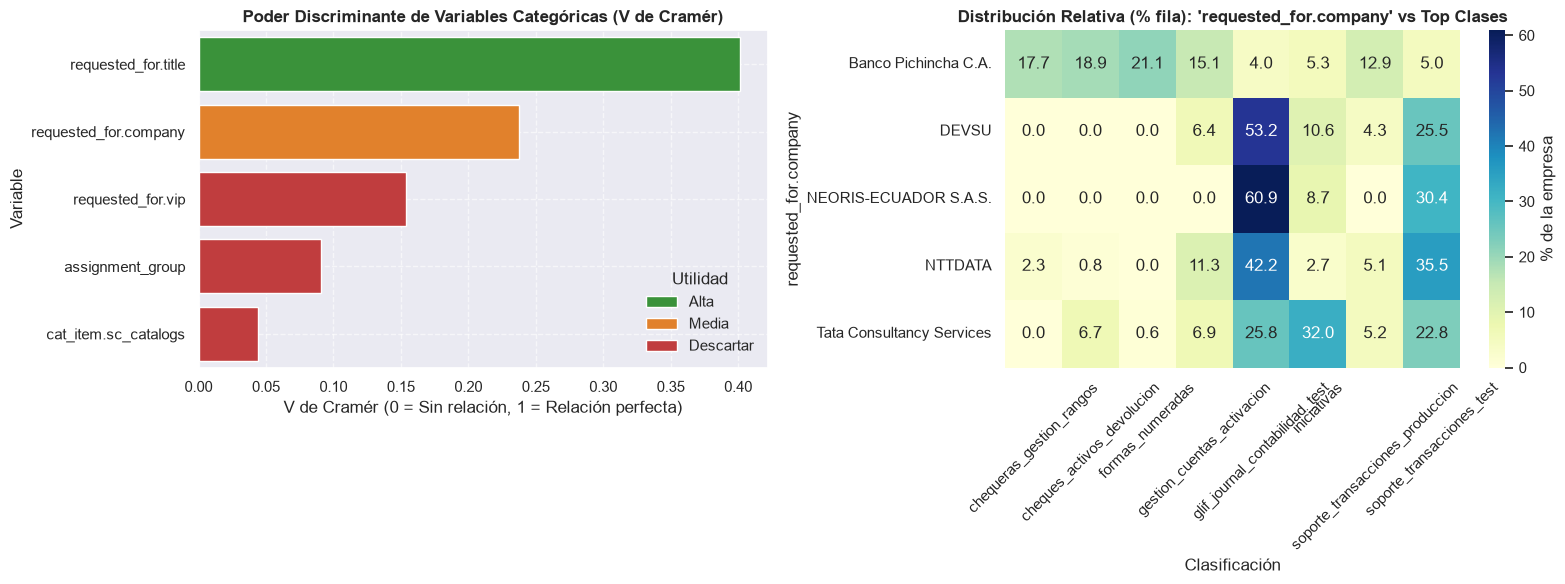

In [12]:
# ==============================================================================
# ANÁLISIS INTEGRAL DE RELEVANCIA DE VARIABLES PARA LA CLASIFICACIÓN DE REQUERIMIENTOS
# ==============================================================================

# 1. Filtrar registros etiquetados válidos para medir asociación real
mask_valido = ~df['Clasificación'].astype(str).str.strip().str.lower().isin(
    ['0', 'nan', 'sin_clasificar', 'pendiente', 'none', '']
) & df['Clasificación'].notnull()

df_eval = df[mask_valido].copy()
print(f"Evaluando relevancia predictiva sobre {len(df_eval)} tickets clasificados ({df_eval['Clasificación'].nunique()} categorías).\n")

# Función para calcular V de Cramér con corrección de sesgo (Bergsma, 2013)
def cramers_v_corrected(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.shape[0] <= 1 or confusion_matrix.shape[1] <= 1:
        return 0.0
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0
    return float(np.sqrt(phi2corr / denom))

# 2. Clasificación funcional de columnas según el ciclo de vida del ticket
columnas_fuga = ['state', 'assigned_to', 'fecha_asignacion']
columnas_id = ['number', 'ref_sc_req_item.requested_for', 'requested_for.email']
columnas_texto = ['short_description', 'description']

columnas_categoricas = [
    col for col in df.columns 
    if col not in columnas_fuga + columnas_id + columnas_texto + ['Clasificación']
    and df[col].nunique() > 1
]

# 3. Evaluación de variables categóricas candidatas
resultados = []
for col in columnas_categoricas:
    s_full = df[col]
    s_eval = df_eval[col].fillna('DESCONOCIDO').astype(str)
    
    nunique = s_full.nunique(dropna=False)
    pct_null = s_full.isnull().mean() * 100
    top_val_pct = (s_full.value_counts(normalize=True, dropna=False).iloc[0]) * 100 if len(s_full) > 0 else 0
    
    cv = cramers_v_corrected(s_eval, df_eval['Clasificación'])
    
    # Diagnóstico y utilidad
    if top_val_pct >= 95.0:
        utilidad = "Descartar"
        motivo = "Cuasi-constante (Varianza nula)"
    elif cv >= 0.35:
        utilidad = "Alta"
        motivo = "Fuerte asociación con Clasificación"
    elif cv >= 0.20:
        utilidad = "Media"
        motivo = "Moderada asociación discriminante"
    else:
        utilidad = "Baja"
        motivo = "Poca capacidad discriminante"
        
    resultados.append({
        'Variable': col,
        'Nulos (%)': round(pct_null, 1),
        'Valores Únicos': nunique,
        'Dominancia Moda (%)': round(top_val_pct, 1),
        "Cramér's V": round(cv, 4),
        'Utilidad': utilidad,
        'Diagnóstico': motivo
    })

df_ranking = pd.DataFrame(resultados).sort_values(by="Cramér's V", ascending=False).reset_index(drop=True)

print("=" * 85)
print("1. RANKING DE RELEVANCIA ESTADÍSTICA (VARIABLES CATEGÓRICAS)")
print("=" * 85)
print(df_ranking[['Variable', 'Nulos (%)', 'Dominancia Moda (%)', "Cramér's V", 'Utilidad', 'Diagnóstico']].to_string(index=False))

# 4. Diagnóstico de campos de texto (NLP)
print("\n" + "=" * 85)
print("2. CAMPOS DE TEXTO (PRINCIPAL FUENTE DE INFORMACIÓN PARA EL CLASIFICADOR)")
print("=" * 85)
for col in columnas_texto:
    if col in df.columns:
        pct_nulos = df[col].isnull().mean() * 100
        avg_len = df[col].fillna('').astype(str).str.len().mean()
        estado = "RECOMENDADA (Core del modelo NLP)" if pct_nulos < 10 else "Opcional (Muchos nulos)"
        print(f"• {col:<25}: {pct_nulos:5.1f}% nulos | Longitud media: {avg_len:5.1f} caracteres -> {estado}")

# 5. Advertencia de Fuga de Información
print("\n" + "=" * 85)
print("3. VARIABLES EXCLUIDAS POR FUGA DE DATOS (DATA LEAKAGE)")
print("=" * 85)
print("Las siguientes columnas NO deben usarse si el modelo clasifica tickets al crearse (estado 'Nuevo'):")
for col in columnas_fuga:
    if col in df.columns:
        print(f"⚠ {col:<25}: Se genera o modifica durante/después de la gestión del requerimiento.")

# 6. Gráficos de Alto Valor
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Barras de Cramér's V ordenadas por utilidad
paleta = {'Alta': '#2ca02c', 'Media': '#ff7f0e', 'Descartar': '#d62728', 'Baja': '#7f7f7f'}
sns.barplot(
    data=df_ranking,
    x="Cramér's V",
    y='Variable',
    hue='Utilidad',
    palette=paleta,
    dodge=False,
    ax=axes[0]
)
axes[0].set_title("Poder Discriminante de Variables Categóricas (V de Cramér)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("V de Cramér (0 = Sin relación, 1 = Relación perfecta)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(title="Utilidad")

# Gráfico B: Distribución de la Variable Top (requested_for.company)
top_col = 'requested_for.company'
top_categorias = df_eval['Clasificación'].value_counts().head(8).index
df_top_clases = df_eval[df_eval['Clasificación'].isin(top_categorias)]
top_companies = df_top_clases[top_col].value_counts().head(5).index
crosstab_norm = pd.crosstab(
    df_top_clases[df_top_clases[top_col].isin(top_companies)][top_col],
    df_top_clases['Clasificación'],
    normalize='index'
) * 100

sns.heatmap(crosstab_norm, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% de la empresa'}, ax=axes[1])
axes[1].set_title(f"Distribución Relativa (% fila): '{top_col}' vs Top Clases", fontsize=12, fontweight='bold')
axes[1].set_ylabel(top_col)
axes[1].set_xlabel("Clasificación")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 5. Enriquecimiento Textual y Resolución de Ambigüedades Humanas

1. Se unifica el texto incorporando los metadatos contextuales relevantes (`short_description`, `description`, `requested_for.title`, `requested_for.company`).
2. Se detectan tickets idénticos que fueron clasificados con diferentes categorías por analistas humanos.
3. Se resuelve la ambigüedad aplicando la regla mayoritaria para eliminar ruido de etiquetas.
4. Se preservan **todos** los registros (sin borrar duplicados) para mantener la frecuencia real del negocio.

In [13]:
# Unificar texto relevante para análisis de similitud y modelado NLP
df['texto_unificado'] = (
    df['short_description'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requested_for.title'].fillna('') + ' ' +
    df['requested_for.company'].fillna('')
)

# Guardar copia del texto crudo ANTES de limpiar (para análisis de duplicados y GroupSplit)
df['texto_unificado_raw'] = df['texto_unificado']

print(f"✓ 'texto_unificado' generado con éxito para {len(df)} registros.")
print(f"  Longitud promedio del texto enriquecido: {df['texto_unificado'].str.len().mean():.1f} caracteres.")


✓ 'texto_unificado' generado con éxito para 9615 registros.
  Longitud promedio del texto enriquecido: 377.4 caracteres.


In [14]:
# ── Análisis de duplicados exactos en texto_unificado (PRE-limpieza) ──────────
dup_mask_raw = df['texto_unificado_raw'].duplicated(keep=False)
df_dups_raw = df[dup_mask_raw].copy()

print(f"Tickets con texto_unificado duplicado (crudo): {dup_mask_raw.sum()}  "
      f"({dup_mask_raw.mean():.1%} del total)")
print(f"Textos únicos que se repiten: {df_dups_raw['texto_unificado_raw'].nunique()}")

# Tabla de frecuencias: cuántas veces se repite cada texto y sus clasificaciones
resumen_dups = (
    df_dups_raw
    .groupby('texto_unificado_raw', as_index=False)
    .agg(
        n_tickets       = ('number', 'count'),
        clasificaciones = ('Clasificación', lambda x: ', '.join(sorted(x.unique()))),
        n_clases        = ('Clasificación', 'nunique'),
        ejemplos        = ('number', lambda x: ', '.join(x.head(4).astype(str)))
    )
    .rename(columns={'texto_unificado_raw': 'texto_unificado'})
    .sort_values('n_tickets', ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 textos más repetidos:")
with pd.option_context('display.max_colwidth', 80):
    display(resumen_dups.head(20))

# Duplicados con clasificaciones distintas (ambigüedad real)
ambiguos = resumen_dups[resumen_dups['n_clases'] > 1]
print(f"\nTextos duplicados con DISTINTAS clasificaciones (ambigüedad): {len(ambiguos)}")
if len(ambiguos):
    with pd.option_context('display.max_colwidth', 80):
        display(ambiguos.head(20))


Tickets con texto_unificado duplicado (crudo): 876  (9.1% del total)
Textos únicos que se repiten: 290

Top 20 textos más repetidos:


,texto_unificado,n_tickets,clasificaciones,n_clases,ejemplos
0,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Motor de Tra...,50,motor_transferencias,1,"RITM0688742, RITM0686756, RITM0722457, RITM0889992"
1,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Por favor su...,23,glif_journal_contabilidad_test,1,"RITM0664878, RITM0626086, RITM0710930, RITM0720138"
2,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Motor de Tra...,18,motor_transferencias,1,"RITM0799404, RITM0837033, RITM0841806, RITM0821836"
3,"Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Estimados, E...",18,soporte_transacciones_test,1,"RITM0710350, RITM0702243, RITM0705916, RITM0690932"
4,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Estimados bu...,13,glif_journal_contabilidad_test,1,"RITM0736989, RITM0474404, RITM0593669, RITM0653714"
5,"Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Estimados, f...",12,reportes_bancslink_online,1,"RITM0130191, RITM0288307, RITM0207608, RITM0143268"
6,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Por favor su...,11,glif_journal_contabilidad_test,1,"RITM0586122, RITM0700741, RITM0629765, RITM0710671"
7,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Por favor su...,10,glif_journal_contabilidad_test,1,"RITM0588500, RITM0591804, RITM0465945, RITM0463987"
8,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Cambiar la p...,10,iniciativas,1,"RITM0694600, RITM0728521, RITM0627712, RITM0496796"
9,Requerimientos de informaciÃ³n relacionados a Bancs y BancsLink Aplicativo: ...,10,soporte_tablas,1,"RITM0768862, RITM0861165, RITM0807919, RITM0881107"



Textos duplicados con DISTINTAS clasificaciones (ambigüedad): 0


In [15]:
# ── IDs de tickets ambiguos (ninguna clasificación es "sin_clasificar") ───────
textos_ambiguos_reales = resumen_dups[
    (resumen_dups['n_clases'] > 1) &
    (~resumen_dups['clasificaciones'].str.contains(r'\bsin_clasificar\b', na=False))
]['texto_unificado'].tolist()

ids_ambiguos = (
    df[df['texto_unificado_raw'].isin(textos_ambiguos_reales)]['number']
    .sort_values()
    .reset_index(drop=True)
)

print(f"Total IDs para revisión: {len(ids_ambiguos)}")
display(ids_ambiguos.to_frame())


Total IDs para revisión: 0


,number


In [16]:
mapa_mayoritario = {}
for texto in textos_ambiguos_reales:
    conteo = (
        df[df['texto_unificado_raw'] == texto]['Clasificación']
        .value_counts()
    )
    mapa_mayoritario[texto] = conteo.idxmax()

mask_ambiguos = df['texto_unificado_raw'].isin(textos_ambiguos_reales)
df.loc[mask_ambiguos, 'Clasificación'] = df.loc[mask_ambiguos, 'texto_unificado_raw'].map(mapa_mayoritario)

print(f"Tickets corregidos: {mask_ambiguos.sum()}")
print("\nClasificación asignada por texto ambiguo:")
for texto, clase in mapa_mayoritario.items():
    print(f" → '{texto[:80]}...' ► {clase}")

verificacion = (
    df[mask_ambiguos]
    .groupby('texto_unificado_raw')['Clasificación']
    .nunique()
)
assert (verificacion == 1).all(), "¡Aún quedan textos con múltiples clases!"
print(f"\n✓ Verificación OK: todos los textos ambiguos tienen ahora una única clasificación.")


Tickets corregidos: 0

Clasificación asignada por texto ambiguo:

✓ Verificación OK: todos los textos ambiguos tienen ahora una única clasificación.


In [17]:
# ── Preservación de registros y preparación para Group Split ────────────────
total_tickets = len(df)
textos_unicos = df['texto_unificado_raw'].nunique()
tickets_repetidos = total_tickets - textos_unicos

print(f"Total de tickets conservados : {total_tickets} (100% de la información preservada)")
print(f"Textos únicos de requerimientos: {textos_unicos}")
print(f"Tickets con textos recurrentes: {tickets_repetidos} ({tickets_repetidos / total_tickets:.1%})")
print(f"-> Nota: No se descarta ningún ticket. El aislamiento train/test se garantizará mediante GroupShuffleSplit.")

print(f"\nDistribución de clases (conteo total de requerimientos):")
print(df['Clasificación'].value_counts().to_string())


Total de tickets conservados : 9615 (100% de la información preservada)
Textos únicos de requerimientos: 9029
Tickets con textos recurrentes: 586 (6.1%)
-> Nota: No se descarta ningún ticket. El aislamiento train/test se garantizará mediante GroupShuffleSplit.

Distribución de clases (conteo total de requerimientos):
Clasificación
formas_numeradas                      730
cheques_activos_devolucion            707
chequeras_gestion_rangos              616
gestion_cuentas_activacion            610
soporte_transacciones_produccion      522
glif_journal_contabilidad_test        496
soporte_transacciones_test            469
iniciativas                           456
opciones_menu_bancslinks              439
incidencias_cuentas_modulos           388
banca_empresas_movimientos            323
certificados_deposito_destruccion     317
operaciones_credito_amortizacion      273
cheques_emergencia_certificados       253
sin_clasificar                        234
facturacion_comisiones_bancarias     

In [18]:
# Cargar stopwords ANTES de limpiar_texto para poder usarlas en la limpieza
nltk.download('stopwords', quiet=True)
spanish_stopwords = set(stopwords.words('spanish'))
print(f"✓ Stopwords cargadas: {len(spanish_stopwords)} palabras")


✓ Stopwords cargadas: 313 palabras


In [19]:
# Importar función centralizada de desidentificación y normalización desde PipelineUtils
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
from Programas.PipelineUtils import clean_and_deidentify_text

limpiar_texto = clean_and_deidentify_text

df['texto_unificado'] = df['texto_unificado'].apply(limpiar_texto)

# Verificar mejora — mostrar muestra de textos limpios
print("Ejemplos de texto limpio (desidentificado y sin stopwords):")
for t in df['texto_unificado'].dropna().sample(5, random_state=42):
    print(" →", t[:120])


Ejemplos de texto limpio (sin stopwords):
 → requerimientos relacionados bancs bancslink reybanpac rey banano pacifico indica genero factura realizada adjunta analis
 → requerimientos relacionados bancs bancslink requerimiento bancslink solicita impresion comprobante accion cambio cuenta 
 → requerimientos relacionados bancs bancslink gentil ayuda desbloqueo cuenta espejo chusquillo macias sonia maribel client
 → requerimientos informacion relacionados bancs bancslink estimados buenas tardes favor ayuda soporte via teams problemas 
 → requerimientos relacionados bancs bancslink estimados gentil ayuda anulacian cheque emergencia emitido hace mas meses vi


## 6. Exportación del Conjunto de Datos Preparado

Se exporta el dataset final curado a `../Datos/Requerimientos_Preparados.csv`.  
Este archivo contiene las etiquetas consolidadas y el `texto_unificado_raw`, listo para ser consumido por los cuadernos de entrenamiento **02 (TF-IDF Baseline)** y **03 (Arquitectura HNLP-MC)**.

In [20]:
# Guardar el DataFrame curado en la carpeta Datos/
ruta_salida_datos = os.path.normpath(os.path.join(os.getcwd(), '..', 'Datos', 'Requerimientos_Preparados.csv'))
os.makedirs(os.path.dirname(ruta_salida_datos), exist_ok=True)

df.to_csv(ruta_salida_datos, sep=';', encoding='latin-1', index=False)

print(f"✓ Dataset preparado exportado exitosamente:")
print(f"  Ruta: {ruta_salida_datos}")
print(f"  Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"  Tickets clasificados: {(df['Clasificación'] != 'sin_clasificar').sum()}")
print(f"  Tickets sin clasificar: {(df['Clasificación'] == 'sin_clasificar').sum()}")


✓ Dataset preparado exportado exitosamente:
  Ruta: z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Requerimientos\Entrenamiento\Datos\Requerimientos_Preparados.csv
  Dimensiones: 9615 filas x 16 columnas
  Tickets clasificados: 9381
  Tickets sin clasificar: 234
